# Big Data and Data Mining – Assignment Report

**Exercise 2 (Facebook Social Network Analysis)**.

## Setup & Configuration

In [2]:
# Importing all necessary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community as community_louvain
from networkx.algorithms.community import girvan_newman
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

## Data Loading

In [3]:
# Loading the Facebook edge list as an undirected graph
G = nx.read_edgelist('facebook_combined-1.txt', create_using=nx.Graph(), nodetype=int)
print(f'Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

Graph loaded: 4,039 nodes, 88,234 edges


## Tasks

#### Network Construction and Basic Characteristics

In [4]:
# Computing basic network statistics
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / n_nodes
avg_clustering = nx.average_clustering(G)
is_connected = nx.is_connected(G)

print(f'Nodes: {n_nodes:,}')
print(f'Edges: {n_edges:,}')
print(f'Density: {density:.6f}')
print(f'Average Degree: {avg_degree:.2f}')
print(f'Avg Clustering: {avg_clustering:.4f}')
print(f'Connected: {is_connected}')

Nodes: 4,039
Edges: 88,234
Density: 0.010820
Average Degree: 43.69
Avg Clustering: 0.6055
Connected: True


In [5]:
# Finding diameter on the largest connected component
lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f'LCC nodes: {lcc.number_of_nodes():,}')
print(f'Diameter: {nx.diameter(lcc)}')

LCC nodes: 4,039
Diameter: 8


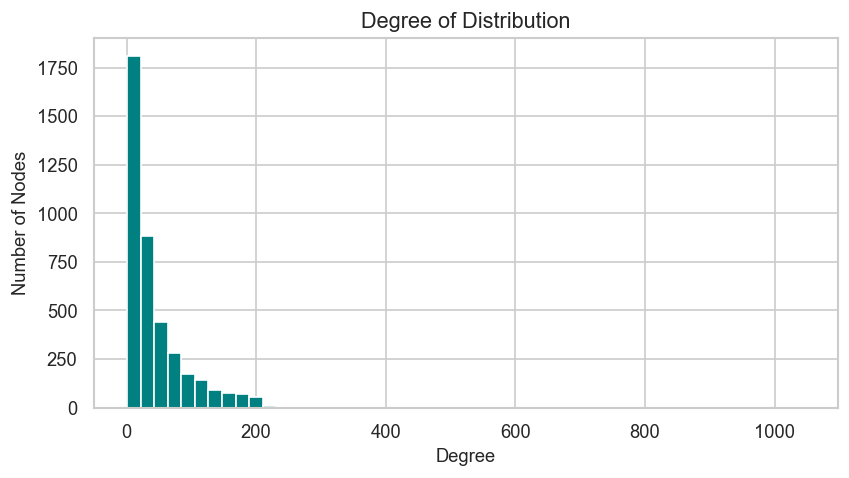

In [6]:
# Degree distribution – linear and log-log scale
degrees = [d for _, d in G.degree()]
deg_series = pd.Series(degrees).value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.hist(degrees, bins=50, color='teal')
plt.title('Degree of Distribution')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')

plt.savefig('ex2_1_degree_distribution.png', bbox_inches='tight')
plt.show()

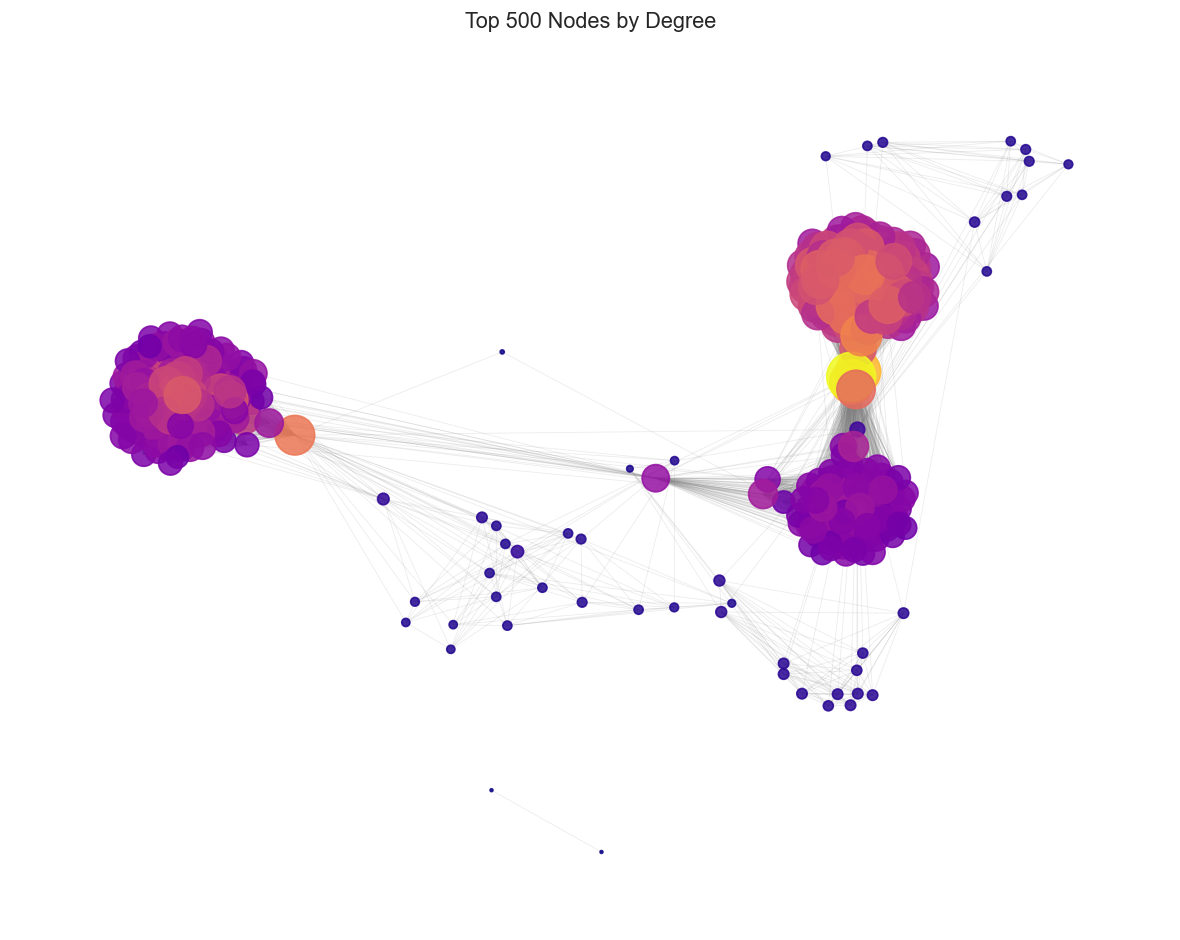

In [7]:
# Visualising the network – top 500 nodes by degree for clarity
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:500]
top_node_ids = [n for n, _ in top_nodes]
G_sub = G.subgraph(top_node_ids).copy()

pos = nx.spring_layout(G_sub, seed=42, k=0.3)
deg_sub = dict(G_sub.degree())
node_sizes = [deg_sub[n] * 3 for n in G_sub.nodes()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G_sub, pos, alpha=0.15, edge_color='grey', width=0.5, ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_sizes, cmap='plasma', alpha=0.85, ax=ax)
ax.set_title('Top 500 Nodes by Degree')
ax.axis('off')
plt.tight_layout()
plt.savefig('ex2_1_network_visualisation.png', bbox_inches='tight')
plt.show()

---
#### Edge Betweenness Centrality

In [8]:
# Computing edge betweenness centrality across all edges
e_b_c = nx.edge_betweenness_centrality(G, normalized=True)
e_b_c_values = list(e_b_c.values())

print(f'Edges analysed: {len(e_b_c_values):,}')
print(f'Min EBC: {min(e_b_c_values):.6f}')
print(f'Max EBC: {max(e_b_c_values):.6f}')
print(f'Mean EBC: {np.mean(e_b_c_values):.6f}')
print(f'Median EBC: {np.median(e_b_c_values):.6f}')

Edges analysed: 88,234
Min EBC: 0.000000
Max EBC: 0.171493
Mean EBC: 0.000042
Median EBC: 0.000001


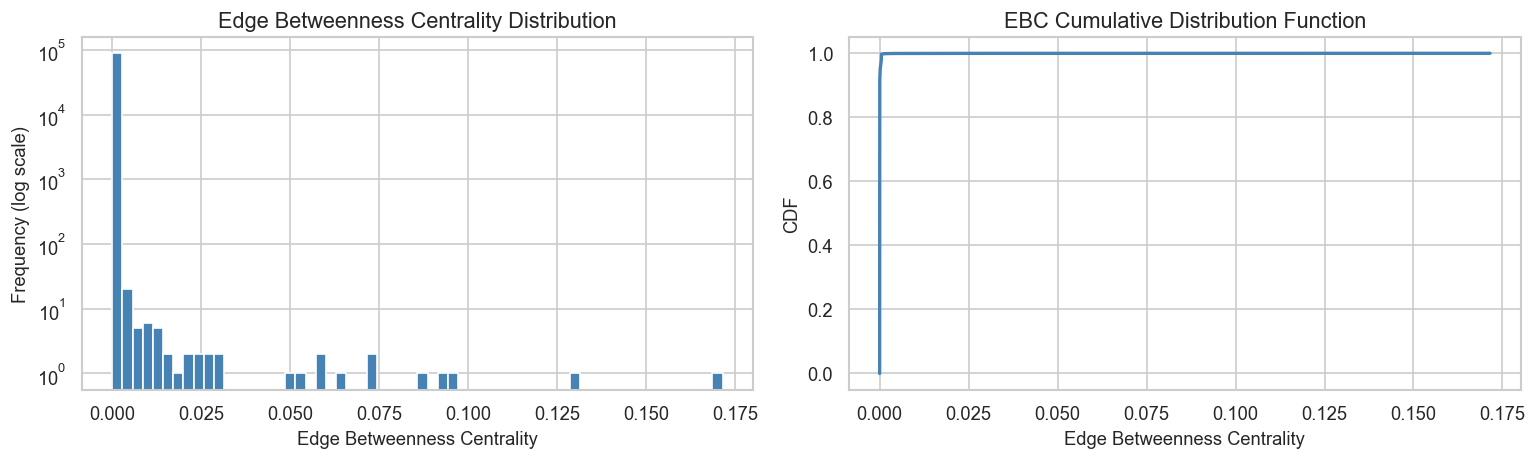

In [9]:
# Plotting EBC distribution and CDF
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(e_b_c_values, bins=60, color='steelblue', log=True)
axes[0].set_title('Edge Betweenness Centrality Distribution')
axes[0].set_xlabel('Edge Betweenness Centrality')
axes[0].set_ylabel('Frequency (log scale)')

# Cumulative distribution
sorted_ebc = np.sort(e_b_c_values)
cdf = np.arange(1, len(sorted_ebc) + 1) / len(sorted_ebc)
axes[1].plot(sorted_ebc, cdf, color='steelblue', linewidth=2)
axes[1].set_title('EBC Cumulative Distribution Function')
axes[1].set_xlabel('Edge Betweenness Centrality')
axes[1].set_ylabel('CDF')

plt.tight_layout()
plt.savefig('ex2_2_ebc_distribution.png', bbox_inches='tight')
plt.show()

In [10]:
# Top 10 edges by EBC
top_edges = sorted(e_b_c.items(), key=lambda x: x[1], reverse=True)[:10]
print('Top 10 edges by betweenness centrality:')
for edge, val in top_edges:
    print(f'  Edge {edge}: EBC = {val:.6f}')

Top 10 edges by betweenness centrality:
  Edge (107, 1684): EBC = 0.171493
  Edge (107, 1085): EBC = 0.129675
  Edge (1085, 3437): EBC = 0.096580
  Edge (567, 3437): EBC = 0.092169
  Edge (0, 107): EBC = 0.088355
  Edge (58, 1684): EBC = 0.072271
  Edge (58, 1912): EBC = 0.071978
  Edge (3437, 698): EBC = 0.064724
  Edge (1684, 860): EBC = 0.058199
  Edge (698, 860): EBC = 0.057890


---
#### Community Detection – Louvain vs Girvan-Newman

In [11]:
# Louvain method for community detection
partition_louvain = community_louvain.best_partition(G, random_state=42)
n_comm_louvain = len(set(partition_louvain.values()))
modularity_louvain = community_louvain.modularity(partition_louvain, G)
louvain_sizes = pd.Series(partition_louvain.values()).value_counts().sort_index()

print(f'Louvain communities: {n_comm_louvain}')
print(f'Louvain modularity: {modularity_louvain:.4f}')
print(f'Largest community: {louvain_sizes.max():,} nodes')
print(f'Smallest community: {louvain_sizes.min():,} nodes')

Louvain communities: 15
Louvain modularity: 0.8349
Largest community: 548 nodes
Smallest community: 19 nodes


In [12]:
# Girvan-Newman for community detection
top_nodes_gn = [n for n, d in sorted(lcc.degree(), key=lambda x: x[1], reverse=True)[:500]]
G_sub_gn = lcc.subgraph(top_nodes_gn).copy()

gn_gen = girvan_newman(G_sub_gn)

# The same number of communities as Louvain for a fair comparison
gn_communities = None
for communities in gn_gen:
    gn_communities = communities
    if len(communities) >= n_comm_louvain:
        break

n_comm_gn = len(gn_communities)
gn_sizes = sorted([len(c) for c in gn_communities], reverse=True)

print(f'Girvan-Newman communities: {n_comm_gn}')
print(f'Largest community: {gn_sizes[0]:,} nodes')
print(f'Smallest community: {gn_sizes[-1]:,} nodes')

Girvan-Newman communities: 15
Largest community: 190 nodes
Smallest community: 1 nodes


In [13]:
# Comparison table of both algorithms
comparison = pd.DataFrame({'Algorithm': ['Louvain', 'Girvan-Newman'], 'Communities': [n_comm_louvain, n_comm_gn], 
                        'Largest Community': [louvain_sizes.max(), gn_sizes[0]], 'Smallest Community': [louvain_sizes.min(), gn_sizes[-1]], 
                        'Mean Size': [round(louvain_sizes.mean(), 1), round(np.mean(gn_sizes), 1)], 'Modularity': [round(modularity_louvain, 4), 'N/A']})
print('Community Detection Comparison:')
print(comparison.to_string(index=False))

Community Detection Comparison:
    Algorithm  Communities  Largest Community  Smallest Community  Mean Size Modularity
      Louvain           15                548                  19      269.3     0.8349
Girvan-Newman           15                190                   1       33.3        N/A


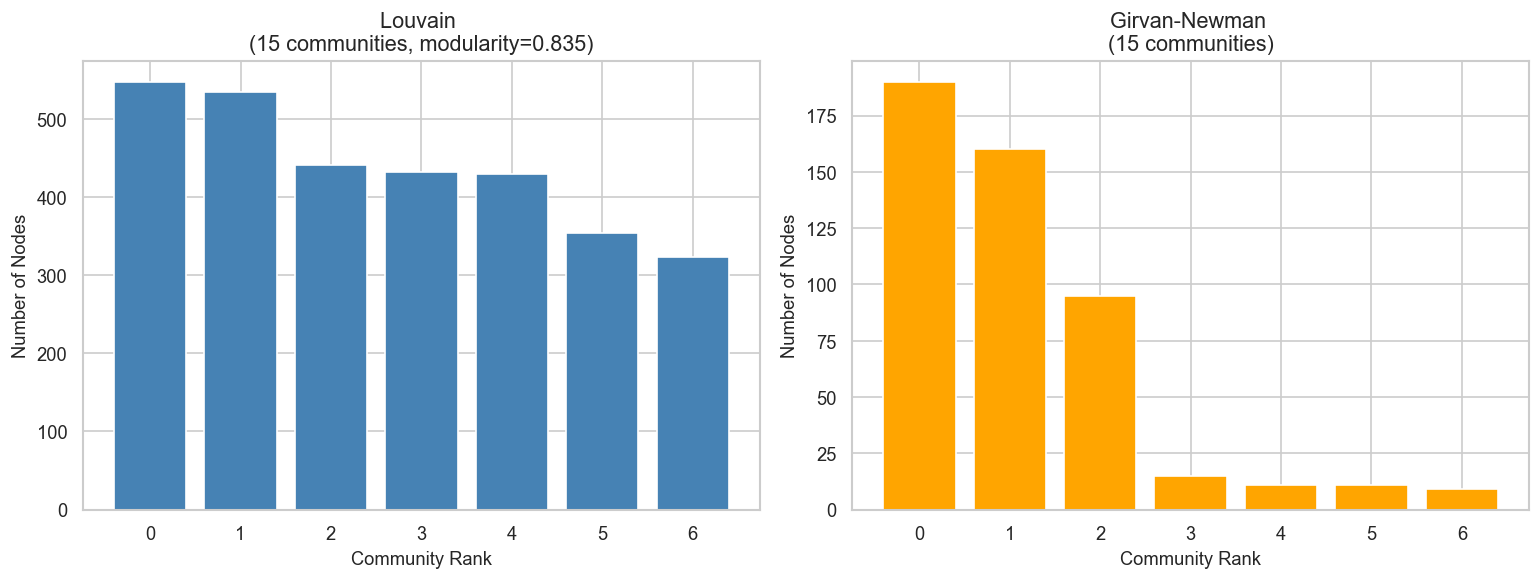

In [14]:
# Plotting community size distributions for both algorithms
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

louvain_top = louvain_sizes.nlargest(7)
axes[0].bar(range(len(louvain_top)), louvain_top.values, color='steelblue')
axes[0].set_title(f'Louvain \n({n_comm_louvain} communities, modularity={modularity_louvain:.3f})')
axes[0].set_xlabel('Community Rank')
axes[0].set_ylabel('Number of Nodes')

axes[1].bar(range(len(gn_sizes[:7])), gn_sizes[:7], color='orange')
axes[1].set_title(f'Girvan-Newman \n({n_comm_gn} communities)')
axes[1].set_xlabel('Community Rank')
axes[1].set_ylabel('Number of Nodes')

plt.tight_layout()
plt.savefig('ex2_3_community_sizes.png', bbox_inches='tight')
plt.show()

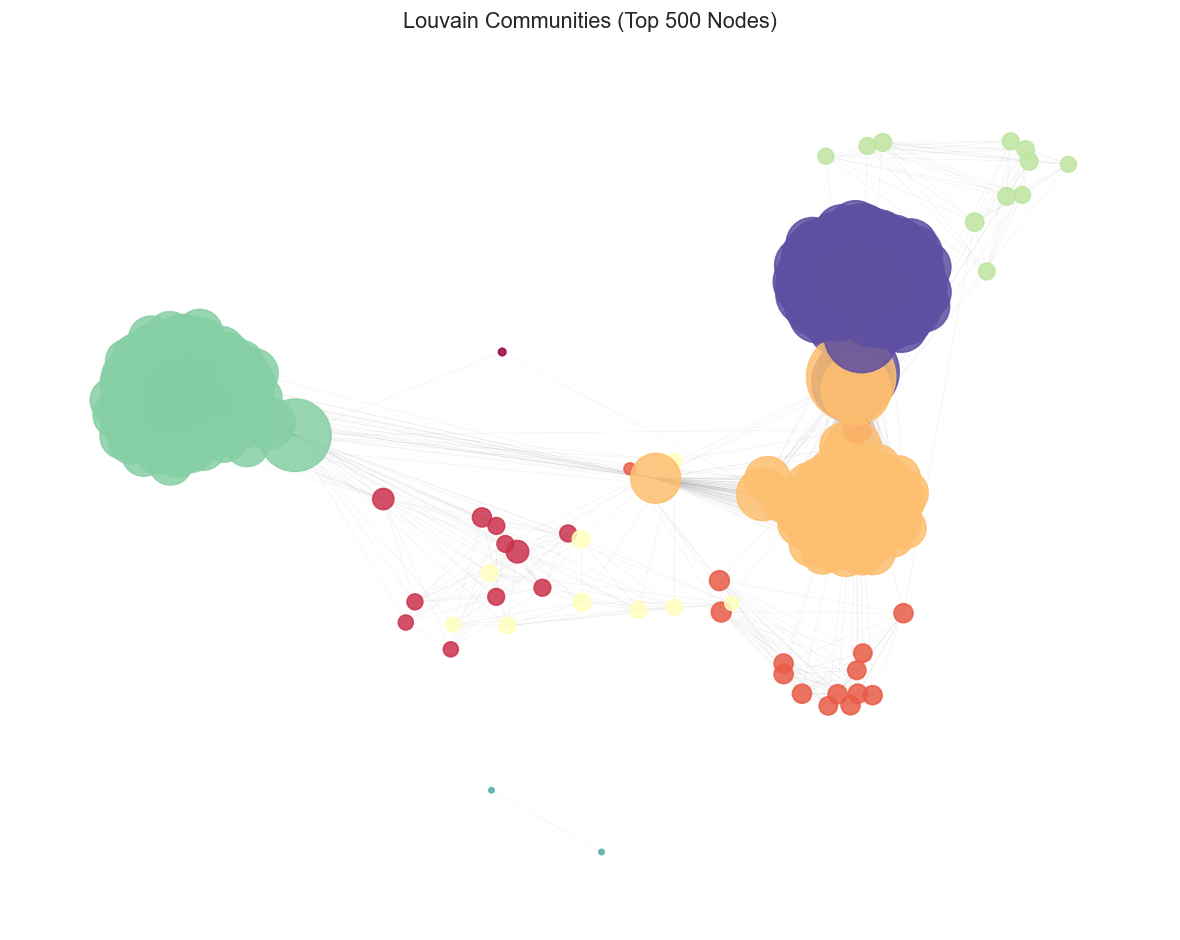

In [15]:
# Visualising Louvain communities on the subgraph
node_colours = [partition_louvain.get(n, 0) for n in G_sub.nodes()]

# Recompute node sizes to match G_sub nodes
node_sizes = [G_sub.degree(n) * 10 for n in G_sub.nodes()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G_sub, pos, alpha=0.1, edge_color='grey', width=0.4, ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_colours, cmap='Spectral', alpha=0.85, ax=ax)
ax.set_title('Louvain Communities (Top 500 Nodes)')
ax.axis('off')
plt.tight_layout()
plt.savefig('ex2_3_louvain_communities.png', bbox_inches='tight')
plt.show()

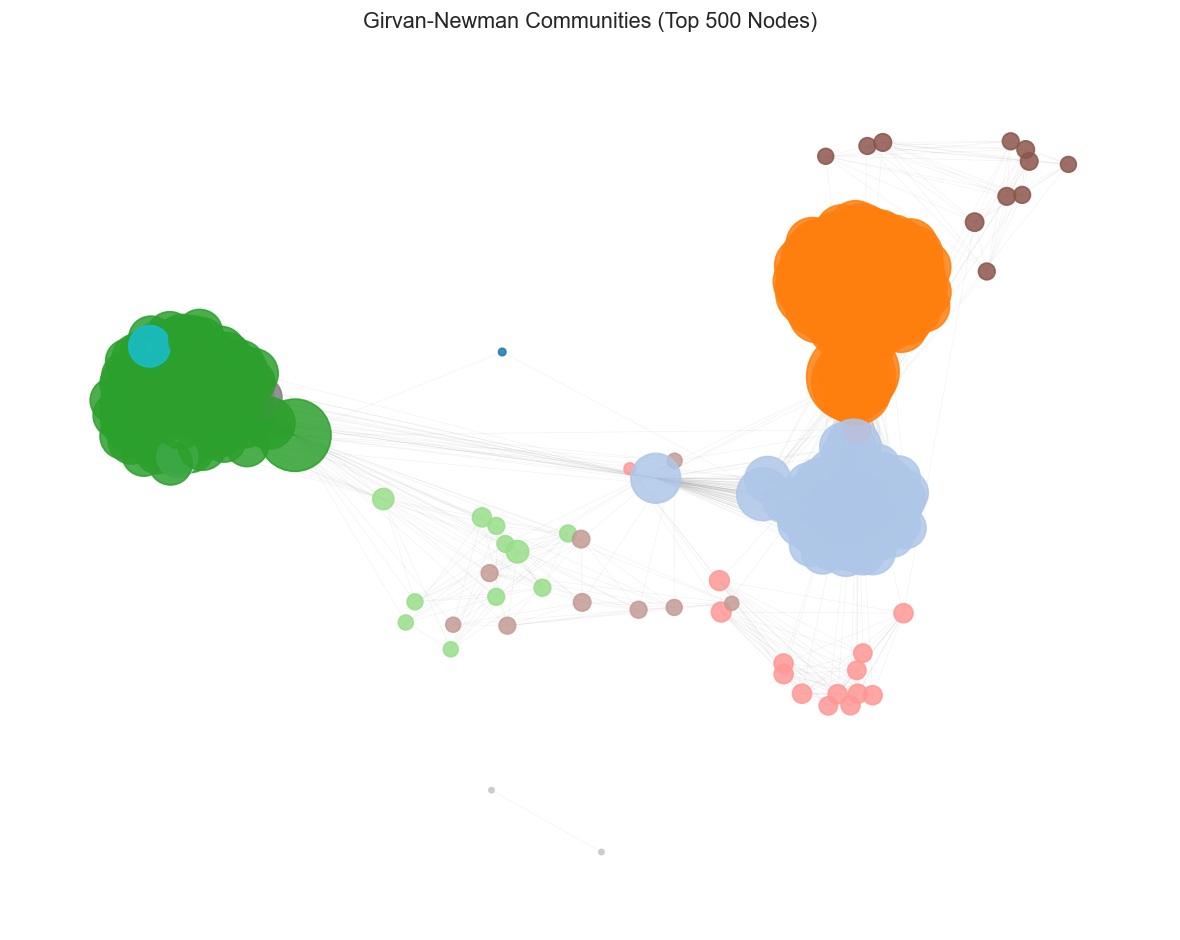

In [16]:
# Visualising Girvan-Newman communities on the subgraph
gn_node_map = {}
for cid, community in enumerate(gn_communities):
    for node in community:
        gn_node_map[node] = cid

gn_colours = [gn_node_map.get(n, -1) for n in G_sub_gn.nodes()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G_sub_gn, pos, alpha=0.1, edge_color='grey', width=0.4, ax=ax)
nx.draw_networkx_nodes(G_sub_gn, pos, node_size=node_sizes, node_color=gn_colours, cmap='tab20', alpha=0.85, ax=ax)
ax.set_title('Girvan-Newman Communities (Top 500 Nodes)')
ax.axis('off')
plt.tight_layout()
plt.savefig('ex2_3_gn_communities.png', bbox_inches='tight')
plt.show()